LIBRARIES IMPOR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET CREATION 

In [2]:
data = {
    'Area_sqft': [1200, 1500, 1800, 2200, 2500, 3000, 1350, 1900, 2800, 3200],
    'Rooms': [2, 3, 3, 4, 4, 5, 2, 3, 4, 5],
    'Location_Rating': [1, 2, 1, 3, 2, 3, 2, 1, 3, 3], 
    'Price': [250000, 320000, 360000, 480000, 510000, 620000, 290000, 370000, 560000, 650000]
}

df = pd.DataFrame(data)
print("--- Dataset Snapshot ---")
print(df.head())

--- Dataset Snapshot ---
   Area_sqft  Rooms  Location_Rating   Price
0       1200      2                1  250000
1       1500      3                2  320000
2       1800      3                1  360000
3       2200      4                3  480000
4       2500      4                2  510000


 DATA VISUALIZATION

Text(0, 0.5, 'Price ($)')

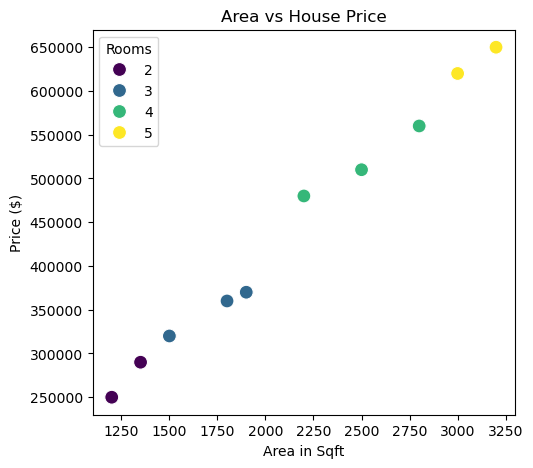

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Area_sqft', y='Price', hue='Rooms', palette='viridis', s=100)
plt.title('Area vs House Price')
plt.xlabel('Area in Sqft')
plt.ylabel('Price ($)')

Features Correlation Heatmap

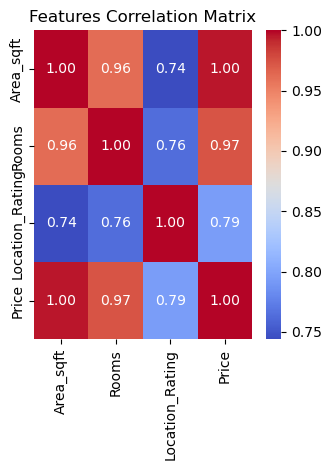

In [4]:
plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Features Correlation Matrix')

plt.tight_layout()
plt.show()

FEATURES AND TARGET VARIABES

In [5]:
X = df[['Area_sqft', 'Rooms', 'Location_Rating']] # Independent variables
y = df['Price']                                   # Dependent/Target variable

 TRAIN-TEST SPLIT (80% Train, 20% Test)

In [7]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

LINEAR REGRESSION MODEL

In [8]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train (fit) the model using training data
model.fit(X_train, y_train)

# Print success message
print("\nModel has been trained successfully!")


Model has been trained successfully!


PREDICTIONS AND EVALUATION

In [9]:
y_pred = model.predict(X_test)

Metrics calculate accuracy

In [11]:
# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared (R²) Score
r2 = r2_score(y_test, y_pred)

# Display the evaluation results
print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²) Score: {r2:.2f}")
print(f"Model Accuracy (R² in %): {r2 * 100:.2f}%")


Mean Squared Error (MSE): 154579493.97
R-squared (R²) Score: 0.99
Model Accuracy (R² in %): 98.93%


Deliverable: Prediction Results

In [12]:
results = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred.round(2)})
print("\n--- Deliverable: Prediction Results ---")
print(results)


--- Deliverable: Prediction Results ---
   Actual Price  Predicted Price
8        560000        569124.56
1        320000        335030.02


 PREDICTION GRAPH

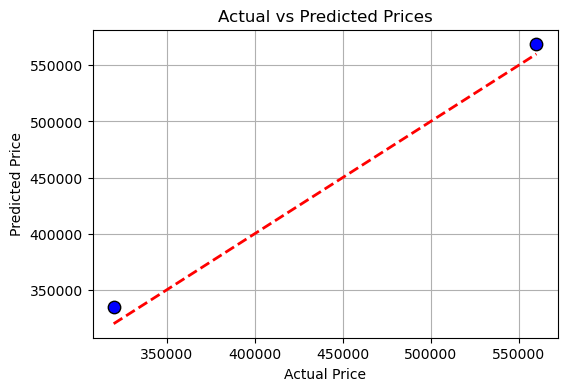

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()